<div style="font-family: 'TeX Gyre Termes', serif; color: black; font-size: 18px;">

### **Simulation Validation**  
**Author: Ramesh Bhatta, CIS, RIT**  
 
This code file is for validating the simulated Bioscape post fire scenes structurally by comparing the canopy height distributions (CHDs) obtained from SfM data and Simulated data.
</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
## Predefined plot preferences

# Define text sizes
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

# Apply text size settings
plt.rc('font', size=SMALL_SIZE)          # Default font size
plt.rc('axes', titlesize=MEDIUM_SIZE)   # Axis title font size
plt.rc('axes', labelsize=MEDIUM_SIZE)   # Axis labels font size
plt.rc('xtick', labelsize=SMALL_SIZE)   # X-axis tick label font size
plt.rc('ytick', labelsize=SMALL_SIZE)   # Y-axis tick label font size
plt.rc('legend', fontsize=SMALL_SIZE)   # Legend font size
plt.rc('figure', titlesize=BIGGER_SIZE) # Figure title font size

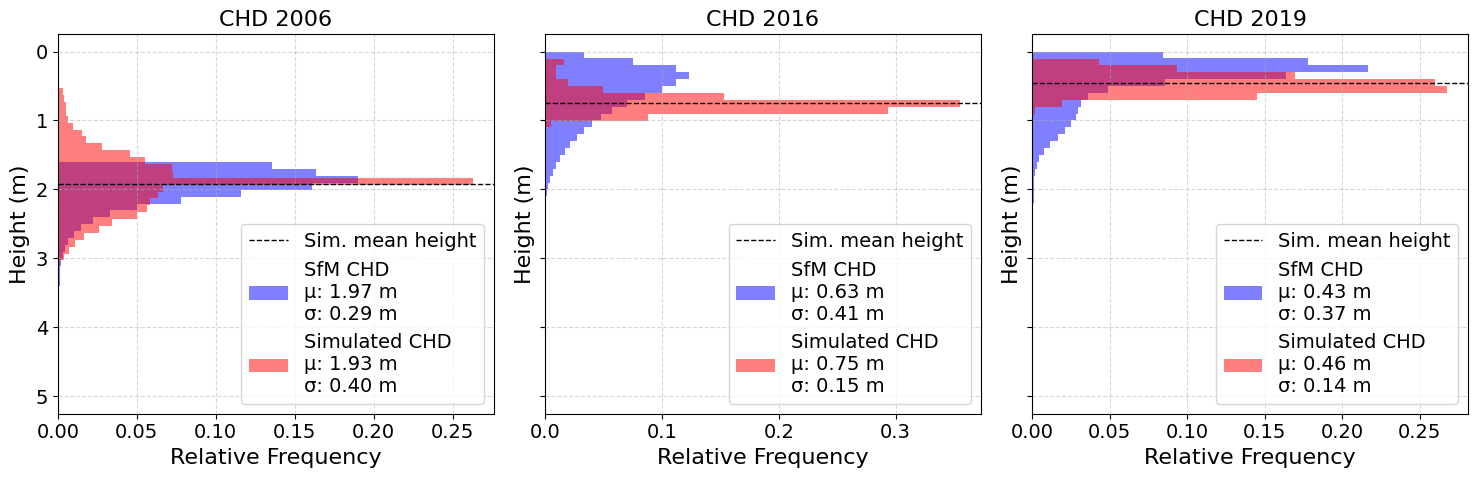

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

def canopy_height_distribution(chm_path, bin_size=0.5, normalize=True,
                               min_height=None, max_height=None, label="", offset=0):
    """
    Compute canopy height distribution from CHM raster.
    """
    # Read raster
    with rasterio.open(chm_path) as src:
        chm = src.read(1).astype(float)

    # Remove no-data and negative values
    chm[chm <= 0] = np.nan
    z = chm[~np.isnan(chm)]

    # Apply offset if needed
    z = z + offset

    # Apply min/max filtering
    if min_height is not None:
        z = z[z >= min_height]
    if max_height is not None:
        z = z[z <= max_height]

    # Create histogram
    z_min = min_height if min_height is not None else z.min()
    z_max = max_height if max_height is not None else z.max()
    bins = np.arange(z_min, z_max + bin_size, bin_size)
    hist, edges = np.histogram(z, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    # Normalize if requested
    if normalize and hist.sum() > 0:
        hist = hist / hist.sum()

    mean, std = np.mean(z), np.std(z)
    return centers, hist, mean, std


if __name__ == "__main__":
    datasets = {
        "2006": {
            "real": "./real_chm_raster/chm_2006.tif",
            "sim": "./simulated_chm_raster/chm_2006.tif",
            "offset": 0
        },
        "2016": {
            "real": "./real_chm_raster/chm_2016.tif",
            "sim": "./simulated_chm_raster/chm_2016.tif",
            "offset": 0
        },
        "2019": {
            "real": "./real_chm_raster/chm_2019.tif",
            "sim": "./simulated_chm_raster/chm_2019.tif",
            "offset": 0
        }
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    for ax, (year, d) in zip(axes, datasets.items()):
        # Real (SfM)
        centers_real, hist_real, mean_real, sigma_real = canopy_height_distribution(
            d["real"], bin_size=0.1, normalize=True, offset=d["offset"]
        )
        ax.barh(centers_real, hist_real, height=0.1, align="center",
                color="blue", alpha=0.5,
                label=f"SfM CHD\nμ: {mean_real:.2f} m\nσ: {sigma_real:.2f} m")

        # Simulated
        centers_sim, hist_sim, mean_sim, sigma_sim = canopy_height_distribution(
            d["sim"], bin_size=0.1, normalize=True, offset=0
        )
        ax.barh(centers_sim, hist_sim, height=0.1, align="center",
                color="red", alpha=0.5,
                label=f"Simulated CHD\nμ: {mean_sim:.2f} m\nσ: {sigma_sim:.2f} m")
        ax.axhline(mean_sim, color="black", linestyle="--", label="Sim. mean height", linewidth=1)


        ax.set_xlabel("Relative Frequency")
        ax.set_ylabel("Height (m)")
        ax.set_title(f"CHD {year}")
        ax.grid(which="both", linestyle="--", alpha=0.5)
        ax.legend(loc="lower right")
        ax.invert_yaxis()

    plt.tight_layout()
    # plt.savefig("canopy_height_distribution_comparison.png", dpi=500)
    plt.show()


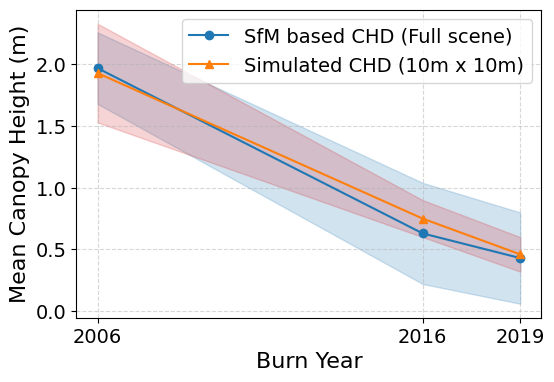

In [16]:
## Plot mean and std deviation of canopy height profiles with respect to year

# Means
sfm_means = np.array([1.97, 0.63, 0.43])
sim_means = np.array([1.93, 0.75, 0.46])

# Stds
sfm_stds = np.array([0.29, 0.41, 0.37])
sim_stds = np.array([0.40, 0.15, 0.14])

years = np.array([2006, 2016, 2019])

# Error
MAE = np.abs(sfm_means - sim_means)

plt.figure(figsize=(6, 4))

# SfM
plt.plot(years, sfm_means, '-o', label='SfM based CHD (Full scene)', color="tab:blue")
plt.fill_between(years, sfm_means - sfm_stds, sfm_means + sfm_stds,
                 color="tab:blue", alpha=0.2)

# Simulation
plt.plot(years, sim_means, '-^', label='Simulated CHD (10m x 10m)', color="tab:orange")
plt.fill_between(years, sim_means - sim_stds, sim_means + sim_stds,
                 color="tab:red", alpha=0.2)

plt.xlabel("Burn Year")
plt.ylabel("Mean Canopy Height (m)")
plt.xticks(years)
plt.grid(which="both", linestyle="--", alpha=0.5)
plt.legend()
# plt.savefig("mean_canopy_height_comparison_2.png", dpi=500)
plt.show()